# PART 1
 getting blobs and ids from db connection

In [2]:
# trying to use the mudular code to get the workflow feeling
import sys
import json

# add app to path so we dont get the error ModuleNotFoundError: No module named 'app'
from pathlib import Path
sys.path.append(str(Path.cwd().parent))
from app.services.database.oracle import OracleService
from app.services.database.mariadb import MariaDBService
from app.utils.db_operations import load_query_from_file, execute_query_to_df
from app.utils.config import load_config
from app.utils.logger import get_logger


logger = get_logger(name=__name__)
config_vars = load_config()

In [2]:

aviso_cirurgia_query_file = "/home/joao/projects/company_projects/carteirinha-api/documents/querys/query_aviso_cirurgia.txt"
aviso_cirurgia_query = load_query_from_file(aviso_cirurgia_query_file)
query_file_path = "/home/joao/projects/company_projects/carteirinha-api/documents/querys/query_numero_carteirinha.txt"
numero_carteirinha_query = load_query_from_file(query_file_path)
query_file_path = "/home/joao/projects/company_projects/carteirinha-api/documents/querys/query_carteirinha.txt"
carteirinha_query = load_query_from_file(query_file_path)

In [4]:
maria_db_carteirinha_df = execute_query_to_df(db_service_class=MariaDBService(settings=config_vars), query=aviso_cirurgia_query, fetch_limit=500)
oracle_db_numero_carteirinha_df = execute_query_to_df(db_service_class=OracleService(settings=config_vars), query=numero_carteirinha_query)
oracle_db_carteirinha_df = execute_query_to_df(db_service_class=OracleService(settings=config_vars), query=carteirinha_query)


{"timestamp": "2025-08-15T14:48:36", "level": "INFO", "name": "app.services.database.mariadb", "message": "✅ MariaDB connection established to\n                srvawsdb002.cow7tj30bxpl.us-east-1.rds.amazonaws.com:3306/", "filename": "mariadb.py", "lineno": 27}
{"timestamp": "2025-08-15T14:48:36", "level": "INFO", "name": "app.services.database.mariadb", "message": "Executing MariaDB query...", "filename": "mariadb.py", "lineno": 67}
{"timestamp": "2025-08-15T14:48:45", "level": "INFO", "name": "app.services.database.mariadb", "message": "✅ Fetched 500 rows from MariaDB.", "filename": "mariadb.py", "lineno": 75}
{"timestamp": "2025-08-15T14:48:45", "level": "INFO", "name": "app.services.database.mariadb", "message": "✅ MariaDB connection closed.", "filename": "mariadb.py", "lineno": 41}
{"timestamp": "2025-08-15T14:48:45", "level": "INFO", "name": "app.utils.db_operations", "message": "✅ Query executed successfully with 500 sample records", "filename": "db_operations.py", "lineno": 57}


In [ ]:
# make some individual df processing if needed
maria_db_carteirinha_df.rename(columns={"surgical_order_id": "CD_AVISO_CIRURGIA", "health_insurance_name": "CONVENIO"}, inplace=True)

In [10]:
# merge the dfs inner join on aviso cirurgia
import pandas as pd

df_merged_oracle = pd.merge(oracle_db_carteirinha_df, oracle_db_numero_carteirinha_df, on="CD_AVISO_CIRURGIA", how="inner")
logger.info("✅ Inner join completed successfully.")

df_merged_final = pd.merge(df_merged_oracle, maria_db_carteirinha_df, on="CD_AVISO_CIRURGIA", how="inner")

df_merged_final.drop_duplicates(subset=["LO_DOCUMENTO_ANEXO_CIRURGICO"], inplace=True)
droppable_cols = [col for col in df_merged_final.columns if col not in ["CD_AVISO_CIRURGIA", "LO_DOCUMENTO_ANEXO_CIRURGICO", 'patient_name', 'CONVENIO', 'NR_CARTEIRA']]
df_merged_final.drop(columns=droppable_cols, inplace=True)
logger.info(df_merged_final.info())
df_merged_final.head()

{"timestamp": "2025-08-15T15:07:19", "level": "INFO", "name": "__main__", "message": "✅ Inner join completed successfully.", "filename": "3573579702.py", "lineno": 5}
{"timestamp": "2025-08-15T15:07:19", "level": "INFO", "name": "__main__", "message": "None", "filename": "3573579702.py", "lineno": 12}


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 226 entries, 0 to 225
Data columns (total 5 columns):
 #   Column                        Non-Null Count  Dtype 
---  ------                        --------------  ----- 
 0   CD_AVISO_CIRURGIA             226 non-null    int64 
 1   LO_DOCUMENTO_ANEXO_CIRURGICO  226 non-null    object
 2   NR_CARTEIRA                   226 non-null    object
 3   patient_name                  226 non-null    object
 4   CONVENIO                      226 non-null    object
dtypes: int64(1), object(4)
memory usage: 9.0+ KB


,CD_AVISO_CIRURGIA,LO_DOCUMENTO_ANEXO_CIRURGICO,NR_CARTEIRA,patient_name,CONVENIO
0,792045,b'%PDF-1.4\n1 0 obj\n<<\n/Title (\xfe\xff\x00D...,891722600159007,NILDA CRISTINA BRAGA RODRIGUES,BRADESCO
1,792058,b'%PDF-1.4\n1 0 obj\n<<\n/Title (\xfe\xff\x00D...,954560112208012,GABRIELLY CELIANA DE REZENDE,BRADESCO
2,792061,b'%PDF-1.4\n1 0 obj\n<<\n/Title (\xfe\xff\x00E...,88888483405330026,LETICIA SCHNEIDER RIBEIRO,SUL AMERICA
3,792062,b'%PDF-1.4\n1 0 obj\n<<\n/Title (\xfe\xff\x00D...,775045002283004,REGINA MARCIA ALVES DE OLIVEIRA,BRADESCO
4,792064,b'%PDF-1.4\n1 0 obj\n<<\n/Title (\xfe\xff\x00D...,772102060828002,VANESSA CRISTINA LEITE,BRADESCO


In [25]:
# save merged df
import sqlalchemy

# Create a database connection
engine = sqlalchemy.create_engine("sqlite:///gold_carteirinha_database.sqlite")


# Save the DataFrame to a SQLite table
df_merged_final.to_sql("carteirinha", engine, if_exists="replace", index=False)

# load 
df_merged_final = pd.read_sql("SELECT * FROM carteirinha", engine)

# part 1.5

In [7]:
# load the dataframe to memory
import sqlalchemy
import pandas as pd

# Create a database connection
engine = sqlalchemy.create_engine("sqlite:///gold_carteirinha_database.sqlite")
df_merged_final = pd.read_sql("SELECT * FROM carteirinha", engine)

In [8]:
# GETTING ids and blobs dict  like ids_and_blobs = {id: blob,id2: blob} from cd aviso and lo docuemnto anexo from df
def get_ids_and_blobs(df: pd.DataFrame) -> dict:
    ids_and_blobs = {}
    for index, row in df.iterrows():
        ids_and_blobs[row['CD_AVISO_CIRURGIA']] = row['LO_DOCUMENTO_ANEXO_CIRURGICO']
    return ids_and_blobs

ids_and_blobs = get_ids_and_blobs(df_merged_final)


# PART 2
 use texttrackt kv and llm reasoning strat to evaluate accuracy on numero carteirinha

In [ ]:
# trying to use the mudular code to get the workflow feeling
import sys

# add app to path so we dont get the error ModuleNotFoundError: No module named 'app'
from pathlib import Path
sys.path.append(str(Path.cwd().parent))
from app.utils.process_images import process_blobs
from app.utils.textract_service import TextractKVExtractor, extract_text_single_id
from app.utils.llm_service import AnthropicLLMService
from app.utils.aws_services_handler import create_boto3_client
from app.utils.config import load_config, AppConstants
from app.utils.logger import get_logger
from app.utils.system_prompts.prompt_handler import Prompts


logger = get_logger(name=__name__)
config_vars = load_config()

In [10]:
app_constants = AppConstants()
texttract_client = create_boto3_client("textract", config_vars)
bedrock_client = create_boto3_client("bedrock-runtime", config_vars)
carteirinha_prompt = Prompts.carteirinha_extraction_prompt

texttract_instance = TextractKVExtractor(texttract_client)
llm_instance = AnthropicLLMService(
    model_id=app_constants.BEDROCK_DEFAULT_MODEL_ID,
    model_version=app_constants.BEDROCK_DEFAULT_MODEL_VERSION,
    client=bedrock_client,
    system_prompt=carteirinha_prompt,
    max_tokens=app_constants.MAX_TOKENS,
    temperature=app_constants.TEMPERATURE,
    budget_tokens=app_constants.BUDGET_TOKENS
)


{"timestamp": "2025-08-18T09:27:10", "level": "INFO", "name": "app.utils.aws_services_handler", "message": "Criando cliente TEXTRACT para a região: us-east-1...", "filename": "aws_services_handler.py", "lineno": 17}
{"timestamp": "2025-08-18T09:27:10", "level": "INFO", "name": "app.utils.aws_services_handler", "message": "Cliente TEXTRACT criado com sucesso.", "filename": "aws_services_handler.py", "lineno": 26}
{"timestamp": "2025-08-18T09:27:10", "level": "INFO", "name": "app.utils.aws_services_handler", "message": "Criando cliente BEDROCK-RUNTIME para a região: us-east-1...", "filename": "aws_services_handler.py", "lineno": 17}
{"timestamp": "2025-08-18T09:27:10", "level": "INFO", "name": "app.utils.aws_services_handler", "message": "Cliente BEDROCK-RUNTIME criado com sucesso.", "filename": "aws_services_handler.py", "lineno": 26}


In [ ]:
# PROCESSING CUSTOM D=DICT WITH IDS AND BLOBS
byte_png_images_and_ids = process_blobs(ids_and_blobs, img_enhancement=False, MAX_IMAGES_PER_BLOB=20)
logger.info(f"Processed {len(byte_png_images_and_ids)} byte PNG images.")

In [13]:
textract_results = {}
llm_results = {}
for id in byte_png_images_and_ids:
    single_id_full_text = extract_text_single_id(images_bytes_list=byte_png_images_and_ids[id],
                                                 textract_instance=texttract_instance, extract_full_text=False)

    textract_results[id] = single_id_full_text
    llm_response = llm_instance.invoke_model(input_str=single_id_full_text)
    llm_results[id] = llm_response

# save to df
textract_results_df = pd.DataFrame.from_dict(textract_results, orient="index")
textract_results_df.index.name = "CD_AVISO_CIRURGIA"
textract_results_df = textract_results_df.reset_index()

llm_results_df = pd.DataFrame.from_dict(llm_results, orient="index")
llm_results_df.index.name = "CD_AVISO_CIRURGIA"
llm_results_df = llm_results_df.reset_index()

# save to sql
import sqlalchemy

# Create a database connection
engine_textract = sqlalchemy.create_engine("sqlite:///textract_results_database.sqlite")
engine_llm = sqlalchemy.create_engine("sqlite:///llm_results_database.sqlite")

textract_results_df.to_sql("textract_results", engine_textract, if_exists="replace", index=False)
llm_results_df.to_sql("llm_results", engine_llm, if_exists="replace", index=False)


ProgrammingError: (sqlite3.ProgrammingError) Error binding parameter 2: type 'dict' is not supported
[SQL: INSERT INTO llm_results ("CD_AVISO_CIRURGIA", llm_response) VALUES (?, ?)]
[parameters: [(792045, {'convenio': None, 'plano': 'SAÚDE TOP ENFERMARIA SEGURO VIAGEM REDE NACIONAL', 'nome_pessoa': 'NILDA CRISTINA BRAGA RODRIGUES', 'numero_carteirinha': '891722600159007'}), (792058, {'convenio': 'BRADESCO', 'plano': None, 'nome_pessoa': 'GABRIELLY CELIANA DE REZENDE', 'numero_carteirinha': '954560112208012'}), (792061, {'convenio': 'SUL AMERICA', 'plano': 'ESPECIAL 100', 'nome_pessoa': 'LETICIA SCHNEIDER RIBEIRO', 'numero_carteirinha': '8884834053300026'}), (792062, {'convenio': None, 'plano': None, 'nome_pessoa': 'REGINA MARCIA ALVES DE OLIVEIRA', 'numero_carteirinha': '775045002283004'}), (792064, {'convenio': None, 'plano': None, 'nome_pessoa': 'VANESSA CRISTINA LEITE', 'numero_carteirinha': '772102060828002'}), (792099, {'convenio': None, 'plano': 'SAÚDE TOP QUARTO', 'nome_pessoa':

In [23]:
textract_results

{792045: 'defaultdict(<class \'list\'>, {\'Passo 3\': [\'Verifique a validade do cartão\'], \'Passo 1\': [\'Verifique se a sua unidade atende o tipo de plano e a rede do beneficiário. Caso o plano seja do tipo "Saúde Hospitalar" ou "Saúde Livre Escolha", o atendimento ambulatorial não está contemplado.\'], \'Consulte aqui as especialidades de acordo com as redes cadastradas em seu(s) código(s):\': [\'X\'], \'Situação\': [\'ATIVO\'], \'Cartão\': [\'891722600159007\'], \'Beneficiário\': [\'NILDA CRISTINA BRAGA RODRIGUES\'], \'CARTÃO NACIONAL DE SAÚDE: 705006296692256\': [\'891 722 600159 007\'], \'Passo 2\': [\'Confirme a titularidade do cartão com o documento de identificação.\'], \'Posição atualizada até o dia\': [\'02/01/2025 às 09:02:16\'], \'SPG\': [\'SAÚDE TOP ENFERMARIA SEGURO VIAGEM REDE NACIONAL NASC.TITULAR: 24/08/1984\'], \'DATA\': [\'\'], \'Verifique todas as redes cadastradas\': [\'Lista de redes\'], \'COLETIVO\': [\'EMPRESARIAL\']})',
 792058: "defaultdict(<class 'list'>, {

In [ ]:


# save to dataframe
textract_results_df = pd.DataFrame.from_dict(textract_results, orient="index")
textract_results_df.index.name = "CD_AVISO_CIRURGIA"
textract_results_df = textract_results_df.reset_index()

llm_results_df = pd.DataFrame.from_dict(llm_results, orient="index")
llm_results_df.index.name = "CD_AVISO_CIRURGIA"
llm_results_df = llm_results_df.reset_index()
llm_results_df.head()

Type of value: <class 'str'>
Content: defaultdict(<class 'list'>, {'Passo 3': ['Verifique a validade do cartão'], 'Passo 1': ['Verifique se a sua unidade atende o tipo de plano e a rede do beneficiário. Caso o plano seja do tipo "Saúde Hospitalar" ou "Saúde Livre Escolha", o atendimento ambulatorial não está contemplado.'], 'Consulte aqui as especialidades de acordo com as redes cadastradas em seu(s) código(s):': ['X'], 'Situação': ['ATIVO'], 'Cartão': ['891722600159007'], 'Beneficiário': ['NILDA CRISTINA BRAGA RODRIGUES'], 'CARTÃO NACIONAL DE SAÚDE: 705006296692256': ['891 722 600159 007'], 'Passo 2': ['Confirme a titularidade do cartão com o documento de identificação.'], 'Posição atualizada até o dia': ['02/01/2025 às 09:02:16'], 'SPG': ['SAÚDE TOP ENFERMARIA SEGURO VIAGEM REDE NACIONAL NASC.TITULAR: 24/08/1984'], 'DATA': [''], 'Verifique todas as redes cadastradas': ['Lista de redes'], 'COLETIVO': ['EMPRESARIAL']})
Type of value: <class 'str'>
Content: defaultdict(<class 'list'>, {

,CD_AVISO_CIRURGIA,convenio,plano,nome_pessoa,numero_carteirinha
0,792045,None,SAÚDE TOP ENFERMARIA SEGURO VIAGEM REDE NACIONAL,NILDA CRISTINA BRAGA RODRIGUES,891722600159007
1,792058,BRADESCO,None,GABRIELLY CELIANA DE REZENDE,954560112208012
2,792061,SUL AMERICA,ESPECIAL 100,LETICIA SCHNEIDER RIBEIRO,8884834053300026
3,792062,None,None,REGINA MARCIA ALVES DE OLIVEIRA,775045002283004
4,792064,None,None,VANESSA CRISTINA LEITE,772102060828002


# Part 3 especial
running in parallel, still needs to check the concurrent apoi calls

In [ ]:
# from concurrent.futures import ThreadPoolExecutor, as_completed

# textract_results = {}
# llm_results = {}

# def process_single_id(id_):
#     # run textract
#     single_id_full_text = extract_text_single_id(
#         images_bytes_list=byte_png_images_and_ids[id_],
#         textract_instance=texttract_instance,
#         extract_full_text=False,
#     )
#     # run llm
#     llm_response = llm_instance.invoke_model(input_str=single_id_full_text)
#     return id_, single_id_full_text, llm_response

# # adjust workers depending on how many concurrent calls you want
# with ThreadPoolExecutor(max_workers=10) as executor:
#     futures = [executor.submit(process_single_id, id_) for id_ in byte_png_images_and_ids]

#     for future in as_completed(futures):
#         id_, text, llm_resp = future.result()
#         textract_results[id_] = text
#         llm_results[id_] = llm_resp
# # save to df
# textract_results_df = pd.DataFrame.from_dict(textract_results, orient="index")
# textract_results_df.index.name = "CD_AVISO_CIRURGIA"
# textract_results_df = textract_results_df.reset_index()

# llm_results_df = pd.DataFrame.from_dict(llm_results, orient="index")
# llm_results_df.index.name = "CD_AVISO_CIRURGIA"
# llm_results_df = llm_results_df.reset_index()

# # save to df
# textract_results_df = pd.DataFrame.from_dict(textract_results, orient="index")
# textract_results_df.index.name = "CD_AVISO_CIRURGIA"
# textract_results_df = textract_results_df.reset_index()

# llm_results_df = pd.DataFrame.from_dict(llm_results, orient="index")
# llm_results_df.index.name = "CD_AVISO_CIRURGIA"
# llm_results_df = llm_results_df.reset_index()

# # save to sql
# import sqlalchemy

# # Create a database connection
# engine_textract = sqlalchemy.create_engine("sqlite:///textract_results_database.sqlite")
# engine_llm = sqlalchemy.create_engine("sqlite:///llm_results_database.sqlite")

# textract_results_df.to_sql("textract_results", engine_textract, if_exists="replace", index=False)
# llm_results_df.to_sql("llm_results", engine_llm, if_exists="replace", index=False)


# Part 3:
## evaluation with generated predictions and actual values from db

In [1]:
import sqlalchemy
import pandas as pd

# Create a database connection
engine = sqlalchemy.create_engine("sqlite:///gold_carteirinha_database.sqlite")
df_merged_final = pd.read_sql("SELECT * FROM carteirinha", engine)

engine_textract = sqlalchemy.create_engine("sqlite:///textract_results_database.sqlite")
engine_llm = sqlalchemy.create_engine("sqlite:///llm_results_database.sqlite")

textract_results_df = pd.read_sql("SELECT * FROM textract_results", engine_textract)
llm_results_df = pd.read_sql("SELECT * FROM llm_results", engine_llm)

In [4]:
df_merged_final.drop(columns=["LO_DOCUMENTO_ANEXO_CIRURGICO"], inplace=True)

In [ ]:
# find values given a specific CD_AVISO_CIRURGIA
textract_results_df.loc[textract_results_df["CD_AVISO_CIRURGIA"] == 793185, "text"].values[0]

"defaultdict(<class 'list'>, {'Ope. Origem:': ['0001'], 'Matricula Antiga:': ['010047412013'], 'Desc. Motivo Negativa:': [''], 'Validade Carteirinha:': ['//'], 'Cód. Motivo Negativa:': [''], 'Via do Cartão:': ['0'], 'Abrangência:': ['01'], 'Intercambio:': ['NÃO'], 'Empresa:': ['GRUPO CEMIG'], 'Produto:': ['PSI'], 'Elegível:': ['SIM'], 'Nome:': ['MARIA DE FATIMA GIACOMELLI DOS SANTOS ALMEIDA'], 'Reg. Operadora ANS:': ['417505'], 'Matricula do Beneficiário: *': ['010047412013'], 'Data de Bloqueio:': ['//'], 'Titular:': ['DAVID FRANCISCO DE ALMEIDA'], 'Cartão Nacional de Saúde:': ['704709791251232']})"

In [31]:
eval_df.loc[eval_df["CD_AVISO_CIRURGIA"] == 793185]

,CD_AVISO_CIRURGIA,real_carteirinha_num,patient_name,real_convenio,convenio,plano,nome_pessoa,numero_carteirinha,match_status
42,793185,00010001018079019,MARIA DE FATIMA GIACOMELLI DOS SANTOS ALMEIDA,CEMIG SAUDE,CEMIG SAUDE,PSI,MARIA DE FATIMA GIACOMELLI DOS SANTOS ALMEIDA,010047412013,Mismatch


In [6]:
df_merged_final.head()

,CD_AVISO_CIRURGIA,NR_CARTEIRA,patient_name,CONVENIO
0,792045,891722600159007,NILDA CRISTINA BRAGA RODRIGUES,BRADESCO
1,792058,954560112208012,GABRIELLY CELIANA DE REZENDE,BRADESCO
2,792061,88888483405330026,LETICIA SCHNEIDER RIBEIRO,SUL AMERICA
3,792062,775045002283004,REGINA MARCIA ALVES DE OLIVEIRA,BRADESCO
4,792064,772102060828002,VANESSA CRISTINA LEITE,BRADESCO


In [10]:

df_merged_final.to_string()
llm_results_df.to_string()
eval_df = pd.merge(df_merged_final, llm_results_df, on="CD_AVISO_CIRURGIA", how="inner")
eval_df.head()

,CD_AVISO_CIRURGIA,NR_CARTEIRA,patient_name,CONVENIO,convenio,plano,nome_pessoa,numero_carteirinha
0,792045,891722600159007,NILDA CRISTINA BRAGA RODRIGUES,BRADESCO,None,SAÚDE TOP ENFERMARIA SEGURO VIAGEM REDE NACIONAL,NILDA CRISTINA BRAGA RODRIGUES,891722600159007
1,792058,954560112208012,GABRIELLY CELIANA DE REZENDE,BRADESCO,BRADESCO,None,GABRIELLY CELIANA DE REZENDE,954560112208012
2,792061,88888483405330026,LETICIA SCHNEIDER RIBEIRO,SUL AMERICA,SUL AMERICA,ESPECIAL 100,LETICIA SCHNEIDER RIBEIRO,8884834053300026
3,792062,775045002283004,REGINA MARCIA ALVES DE OLIVEIRA,BRADESCO,None,None,REGINA MARCIA ALVES DE OLIVEIRA,775045002283004
4,792064,772102060828002,VANESSA CRISTINA LEITE,BRADESCO,None,None,VANESSA CRISTINA LEITE,772102060828002


In [11]:
eval_df.rename(columns={"NR_CARTEIRA": "real_carteirinha_num", "CONVENIO": "real_convenio"}, inplace=True)

In [12]:
eval_df.head()

,CD_AVISO_CIRURGIA,real_carteirinha_num,patient_name,real_convenio,convenio,plano,nome_pessoa,numero_carteirinha
0,792045,891722600159007,NILDA CRISTINA BRAGA RODRIGUES,BRADESCO,None,SAÚDE TOP ENFERMARIA SEGURO VIAGEM REDE NACIONAL,NILDA CRISTINA BRAGA RODRIGUES,891722600159007
1,792058,954560112208012,GABRIELLY CELIANA DE REZENDE,BRADESCO,BRADESCO,None,GABRIELLY CELIANA DE REZENDE,954560112208012
2,792061,88888483405330026,LETICIA SCHNEIDER RIBEIRO,SUL AMERICA,SUL AMERICA,ESPECIAL 100,LETICIA SCHNEIDER RIBEIRO,8884834053300026
3,792062,775045002283004,REGINA MARCIA ALVES DE OLIVEIRA,BRADESCO,None,None,REGINA MARCIA ALVES DE OLIVEIRA,775045002283004
4,792064,772102060828002,VANESSA CRISTINA LEITE,BRADESCO,None,None,VANESSA CRISTINA LEITE,772102060828002


In [13]:
# create a col called match status
eval_df["match_status"] = eval_df.apply(
    lambda row: "Match" if row["numero_carteirinha"] == row["real_carteirinha_num"] else "Mismatch",
    axis=1
)

In [20]:
eval_df.head()

,CD_AVISO_CIRURGIA,real_carteirinha_num,patient_name,real_convenio,convenio,plano,nome_pessoa,numero_carteirinha,match_status
0,792045,891722600159007,NILDA CRISTINA BRAGA RODRIGUES,BRADESCO,None,SAÚDE TOP ENFERMARIA SEGURO VIAGEM REDE NACIONAL,NILDA CRISTINA BRAGA RODRIGUES,891722600159007,Match
1,792058,954560112208012,GABRIELLY CELIANA DE REZENDE,BRADESCO,BRADESCO,None,GABRIELLY CELIANA DE REZENDE,954560112208012,Match
2,792061,88888483405330026,LETICIA SCHNEIDER RIBEIRO,SUL AMERICA,SUL AMERICA,ESPECIAL 100,LETICIA SCHNEIDER RIBEIRO,8884834053300026,Mismatch
3,792062,775045002283004,REGINA MARCIA ALVES DE OLIVEIRA,BRADESCO,None,None,REGINA MARCIA ALVES DE OLIVEIRA,775045002283004,Match
4,792064,772102060828002,VANESSA CRISTINA LEITE,BRADESCO,None,None,VANESSA CRISTINA LEITE,772102060828002,Match


In [17]:
textract_results_df.head()

,CD_AVISO_CIRURGIA,text
0,792045,"defaultdict(<class 'list'>, {'Passo 3': ['Veri..."
1,792058,"defaultdict(<class 'list'>, {'GABRIELLY CELIAN..."
2,792061,"defaultdict(<class 'list'>, {'Telefone:': ['']..."
3,792062,"defaultdict(<class 'list'>, {'Passo 1': ['Veri..."
4,792064,"defaultdict(<class 'list'>, {'Beneficiário': [..."


In [24]:
# find the value
textract_results_df["CD_AVISO_CIRURGIA"]

0      792045
1      792058
2      792061
3      792062
4      792064
        ...  
221    796397
222    796416
223    796460
224    796463
225    796491
Name: CD_AVISO_CIRURGIA, Length: 226, dtype: int64

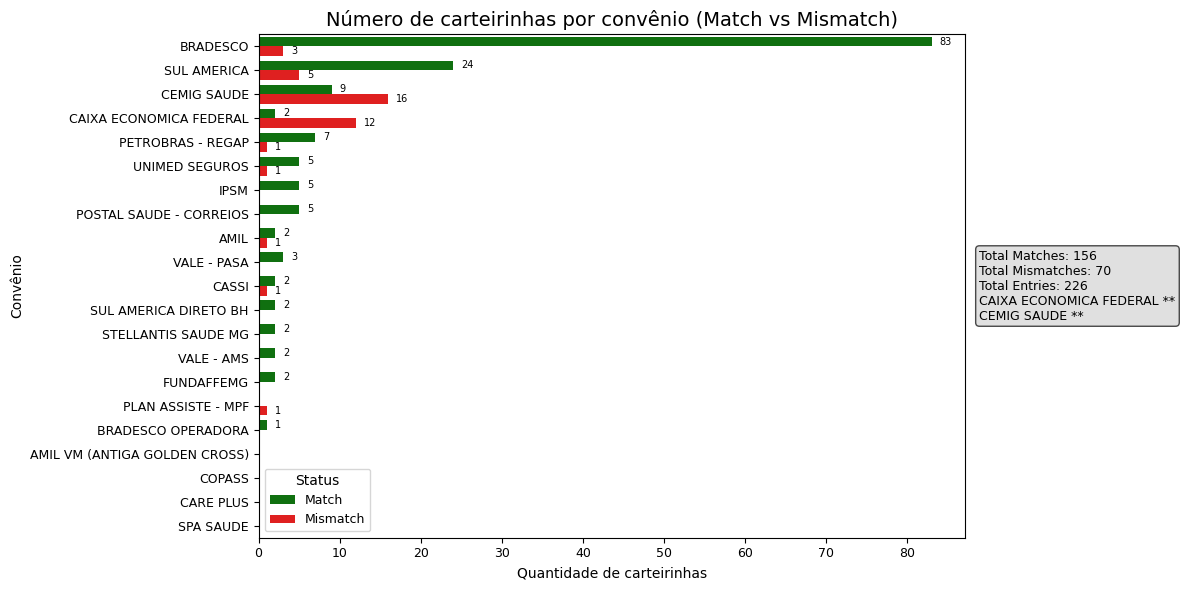

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a match/mismatch column
eval_df["match_status"] = eval_df.apply(
    lambda row: "Match" if row["numero_carteirinha"] == row["real_carteirinha_num"] else "Mismatch",
    axis=1
)

# Group by convenio + match/mismatch
df_counts = (
    eval_df.groupby(["real_convenio", "match_status"])["numero_carteirinha"]
    .count()  
    .reset_index(name="count")
)

# Sort by total count per convenio
order = (
    df_counts.groupby("real_convenio")["count"]
    .sum()
    .sort_values(ascending=False)
    .index
)

# Custom color mapping
custom_palette = {
    "Match": "green",
    "Mismatch": "red"
}

# Plot grouped bars
plt.figure(figsize=(12, 6))
ax = sns.barplot(
    data=df_counts,
    y="real_convenio",
    x="count",
    hue="match_status",
    order=order,
    palette=custom_palette
)

plt.title("Número de carteirinhas por convênio (Match vs Mismatch)", fontsize=14)
plt.xlabel("Quantidade de carteirinhas", fontsize=10)
plt.ylabel("Convênio", fontsize=10)

# Reduce font size of tick labels
ax.tick_params(axis='x', labelsize=9)
ax.tick_params(axis='y', labelsize=9)
plt.legend(title="Status", fontsize=9, title_fontsize=10)

# Annotate each bar with its count
for p in ax.patches:
    width = p.get_width()
    if width > 0:
        ax.text(
            width + 1,
            p.get_y() + p.get_height() / 2,
            int(width),
            va="center",
            fontsize=7
        )

# Calculate totals
total_matches = eval_df[eval_df["match_status"] == "Match"].shape[0]
total_mismatches = eval_df[eval_df["match_status"] == "Mismatch"].shape[0]
total = total_matches + total_mismatches

# Text content
textstr = (
    f"Total Matches: {total_matches}\n"
    f"Total Mismatches: {total_mismatches}\n"
    f"Total Entries: {total}\n"
    f"CAIXA ECONOMICA FEDERAL **\n"
    f"CEMIG SAUDE **"
)

# Add a box with the text inside the plot
props = dict(boxstyle='round', facecolor='lightgray', alpha=0.7)
ax.text(
    1.02, 0.5, textstr, transform=ax.transAxes, fontsize=9,
    verticalalignment='center', bbox=props
)

plt.tight_layout()
plt.show()






# 4 - pinpoint on some health plans to see the potential

In [27]:
# Filter results for CEMIG SAUDE where match status is Mismatch
df_cemig_mismatch = eval_df[
    (eval_df["real_convenio"] == "CEMIG SAUDE") &
    (eval_df["match_status"] == "Mismatch")
].copy()  # copy to avoid SettingWithCopyWarning

# Ensure both columns are strings with at least 12 digits
numero_str = df_cemig_mismatch["numero_carteirinha"].astype(str).str.zfill(12)
real_str = df_cemig_mismatch["real_carteirinha_num"].astype(str).str.zfill(12)

# Compare last 12 digits vectorized
df_cemig_mismatch["potential_match"] = ["Potential Match" if n[-12:] == r[-12:] else "No Match" 
                                        for n, r in zip(numero_str, real_str)]

df_cemig_mismatch


,CD_AVISO_CIRURGIA,real_carteirinha_num,patient_name,real_convenio,convenio,plano,nome_pessoa,numero_carteirinha,match_status,potential_match
26,792987,00010001009043031,EUNICE MARTINS DA SILVA BAPTISTA,CEMIG SAUDE,CEMIG SAUDE,None,EUNICE MARTINS DA SILVA BAPTISTA,010023941031,Mismatch,No Match
30,793035,010037796065,LUCAS BRANDAO ROSA,CEMIG SAUDE,CEMIG SAUDE,None,LUCAS BRANDAO ROSA,00010001001320044,Mismatch,No Match
36,793125,00000010016097046,SANDRA DAS GRACAS SERNIZON SILVEIRA,CEMIG SAUDE,CEMIG SAUDE,PSI,SANDRA GRACAS SERNIZON SILVEIRA,010016097046,Mismatch,Potential Match
42,793185,00010001018079019,MARIA DE FATIMA GIACOMELLI DOS SANTOS ALMEIDA,CEMIG SAUDE,CEMIG SAUDE,PSI,MARIA DE FATIMA GIACOMELLI DOS SANTOS ALMEIDA,010047412013,Mismatch,No Match
47,793280,00010001025184019,BRUNA ANDRADE FERREIRA VERSIANI,CEMIG SAUDE,CEMIG SAUDE,PRATA CR 3 APTO,None,951276154404061302,Mismatch,No Match
49,793288,00010001010546017,MARIA GORETTI DE MELLO SOARES,CEMIG SAUDE,CEMIG SAUDE,PSI,MARIA GORETTI DE MELLO SOARES,010028973013,Mismatch,No Match
72,793792,00010001018384040,ISABELLI MARIA CARVALHO PANTALEÃO,CEMIG SAUDE,None,None,ISABELLI MARIA CARVALHO PANTALEAO,160048435065,Mismatch,No Match
98,794145,00010001017859010,EDLENE ALMEIDA NETO CALDEIRA,CEMIG SAUDE,CEMIG SAUDE,PSI,EDLENE ALMEIDA NETO CALDEIRA,010046934013,Mismatch,No Match
106,794365,00010001016744040,GABRIEL JARDIM DE OLIVEIRA,CEMIG SAUDE,CEMIG SAUDE,PSI,GABRIEL JARDIM DE OLIVEIRA,010042768047,Mismatch,No Match
109,794430,00010001009566000,ROBESPIERRE MOURAO VILANI,CEMIG SAUDE,CEMIG SAUDE,None,ROBESPIERRE MOURAO VILANI,010025814002,Mismatch,No Match


not a lot of good results for cemig

In [40]:
# caixa
# Filter results for CAIXA ECONOMICA FEDERAL where match status is Mismatch
# Filter results for CAIXA ECONOMICA FEDERAL where match status is Mismatch
df_caixa_mismatch = eval_df[
    (eval_df["real_convenio"] == "CAIXA ECONOMICA FEDERAL") &
    (eval_df["match_status"] == "Mismatch")
].copy()  # copy to avoid SettingWithCopyWarning

# Ensure both columns are strings
numero_str = df_caixa_mismatch["numero_carteirinha"].astype(str)
real_str = df_caixa_mismatch["real_carteirinha_num"].astype(str)

# Check if numero_carteirinha matches the start of real_numero_carteirinha
df_caixa_mismatch["potential_match"] = ["Potential Match" if r.startswith(n) else "No Match" 
                                        for n, r in zip(numero_str, real_str)]

df_caixa_mismatch

,CD_AVISO_CIRURGIA,real_carteirinha_num,patient_name,real_convenio,convenio,plano,nome_pessoa,numero_carteirinha,match_status,potential_match
14,792422,0101407360000254,JULIANA GRECHI TASSARA REIS,CAIXA ECONOMICA FEDERAL,None,None,JULIANA GRECHI TASSARA REIS,010140736000,Mismatch,Potential Match
24,792915,5400007084020193,ANA CAROLINA SALLES ASSIMOS,CAIXA ECONOMICA FEDERAL,None,None,ANA CAROLINA SALLES ASSIMOS,540000708402,Mismatch,Potential Match
28,793016,0101499958010209,TAIENY COSTA ABDALA,CAIXA ECONOMICA FEDERAL,None,None,TAIENY COSTA ABDALA,010149995801,Mismatch,Potential Match
37,793127,0104557722010234,IVANETE RAMOS MACIEL,CAIXA ECONOMICA FEDERAL,None,None,IVANETE RAMOS MACIEL,010455772201,Mismatch,Potential Match
41,793182,0101439608010278,FERNANDA SOUZA BARRETO,CAIXA ECONOMICA FEDERAL,None,None,FERNANDA SOUZA BARRETO,010143960801,Mismatch,Potential Match
103,794312,0100120436000659,FERNANDO AUGUSTO VAZ FILHO,CAIXA ECONOMICA FEDERAL,None,None,FERNANDO AUGUSTO VAZ FILHO,None,Mismatch,No Match
110,794436,0101362308001259,ANTONIO LAU PINTO,CAIXA ECONOMICA FEDERAL,None,None,ANTONIO LAU PINTO,010136230800,Mismatch,Potential Match
124,794725,0100409278011323,HELVECIO SILVEIRA DE MAGALHAES,CAIXA ECONOMICA FEDERAL,None,None,HELVECIO SILVEIRA DE MAGALHAES,010040927801,Mismatch,Potential Match
142,795182,0100923740011139,ANGELITA MARIA TAVARES,CAIXA ECONOMICA FEDERAL,None,None,ANGELITA MARIA TAVARES,010092374001,Mismatch,Potential Match
155,795345,0100958890030350,WALBER ROBERTO CINTRA,CAIXA ECONOMICA FEDERAL,None,None,WALBER ROBERTO CINTRA,010095889003,Mismatch,Potential Match


good news for caixa 

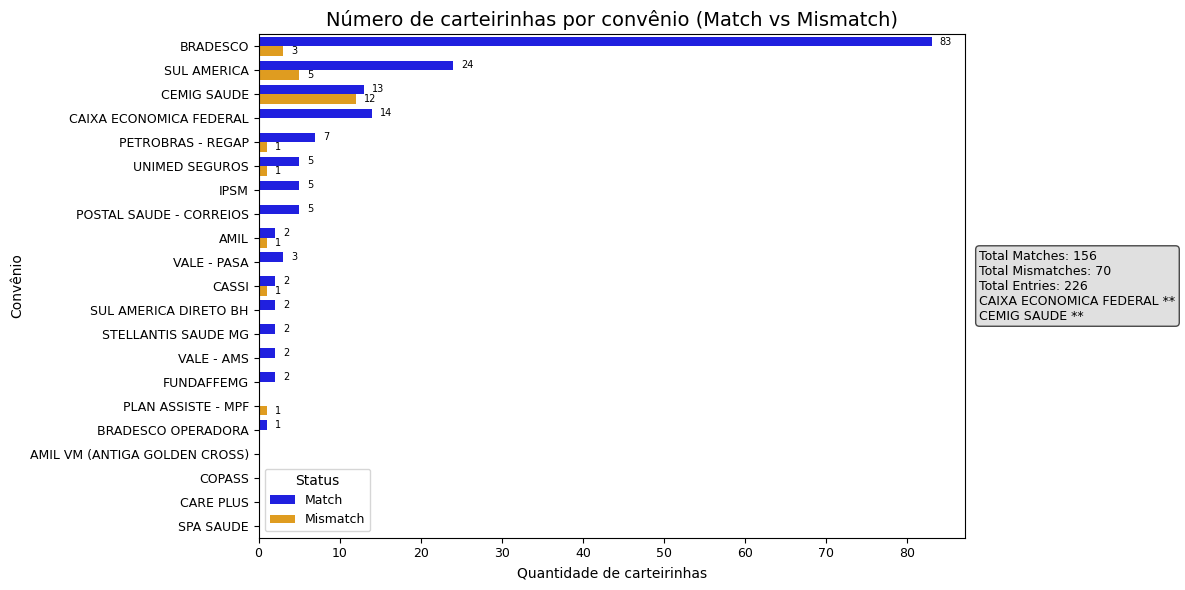

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a match/mismatch column
eval_df["match_status"] = eval_df.apply(
    lambda row: "Match" if row["numero_carteirinha"] == row["real_carteirinha_num"] else "Mismatch",
    axis=1
)

# Group by convenio + match/mismatch
df_counts = (
    eval_df.groupby(["real_convenio", "match_status"])["numero_carteirinha"]
    .count()  
    .reset_index(name="count")
)

# Adjust counts for CEMIG SAUDE
df_counts.loc[
    (df_counts["real_convenio"] == "CEMIG SAUDE") & (df_counts["match_status"] == "Match"),
    "count"
] += 4

df_counts.loc[
    (df_counts["real_convenio"] == "CEMIG SAUDE") & (df_counts["match_status"] == "Mismatch"),
    "count"
] -= 4

# adjusts for CAIXA ECONOMICA FEDERAL
df_counts.loc[
    (df_counts["real_convenio"] == "CAIXA ECONOMICA FEDERAL") & (df_counts["match_status"] == "Match"),
    "count"
] += 12

df_counts.loc[
    (df_counts["real_convenio"] == "CAIXA ECONOMICA FEDERAL") & (df_counts["match_status"] == "Mismatch"),
    "count"
] -= 12

# Sort by total count per convenio
order = (
    df_counts.groupby("real_convenio")["count"]
    .sum()
    .sort_values(ascending=False)
    .index
)

# Custom color mapping, MATCH BLUE, mismatch = orange
custom_palette = {
    "Match": "blue",
    "Mismatch": "orange"
}

# Plot grouped bars
plt.figure(figsize=(12, 6))
ax = sns.barplot(
    data=df_counts,
    y="real_convenio",
    x="count",
    hue="match_status",
    order=order,
    palette=custom_palette
)

plt.title("Número de carteirinhas por convênio (Match vs Mismatch)", fontsize=14)
plt.xlabel("Quantidade de carteirinhas", fontsize=10)
plt.ylabel("Convênio", fontsize=10)

# Reduce font size of tick labels
ax.tick_params(axis='x', labelsize=9)
ax.tick_params(axis='y', labelsize=9)
plt.legend(title="Status", fontsize=9, title_fontsize=10)

# Annotate each bar with its count
for p in ax.patches:
    width = p.get_width()
    if width > 0:
        ax.text(
            width + 1,
            p.get_y() + p.get_height() / 2,
            int(width),
            va="center",
            fontsize=7
        )

# Calculate totals
total_matches = eval_df[eval_df["match_status"] == "Match"].shape[0]
total_mismatches = eval_df[eval_df["match_status"] == "Mismatch"].shape[0]
total = total_matches + total_mismatches

# Text content
textstr = (
    f"Total Matches: {total_matches}\n"
    f"Total Mismatches: {total_mismatches}\n"
    f"Total Entries: {total}\n"
    f"CAIXA ECONOMICA FEDERAL **\n"
    f"CEMIG SAUDE **"
)

# Add a box with the text inside the plot
props = dict(boxstyle='round', facecolor='lightgray', alpha=0.7)
ax.text(
    1.02, 0.5, textstr, transform=ax.transAxes, fontsize=9,
    verticalalignment='center', bbox=props
)

plt.tight_layout()
plt.show()



In [ ]:
# Adjust counts for CEMIG SAUDE
df_counts.loc[
    (df_counts["real_convenio"] == "CEMIG SAUDE") & (df_counts["match_status"] == "Match"),
    "count"
] += 4

df_counts.loc[
    (df_counts["real_convenio"] == "CEMIG SAUDE") & (df_counts["match_status"] == "Mismatch"),
    "count"
] -= 4